# QC and Preprocessing


This notebook performs quality control and preprocessing for a small single-cell RNA-seq dataset using Scanpy.

The aim is to understand how raw single-cell count data is inspected, filtered, normalised, and prepared for downstream clustering.

In [1]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

Dataset is obtain from 10X Genomics containing 3k PBMCs from a Healthy Donor.

In [2]:
adata = sc.datasets.pbmc3k()
adata

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [4]:
print(adata.shape)
adata.obs.head()

(2700, 32738)


""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1


In [5]:
adata.var.head()

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945


## QC

We want to inspect if all the cells are of quality. Here, we want to remove cells that ara damaged, empty droplets, and other technical artefacts.

In [7]:
# find mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# QC
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

adata.obs.head()

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
index,,,,
AAACATACAACCAC-1,781,2421.0,73.0,3.015283
AAACATTGAGCTAC-1,1352,4903.0,186.0,3.793596
AAACATTGATCAGC-1,1131,3149.0,28.0,0.889171
AAACCGTGCTTCCG-1,960,2639.0,46.0,1.743085
AAACCGTGTATGCG-1,522,981.0,12.0,1.223242


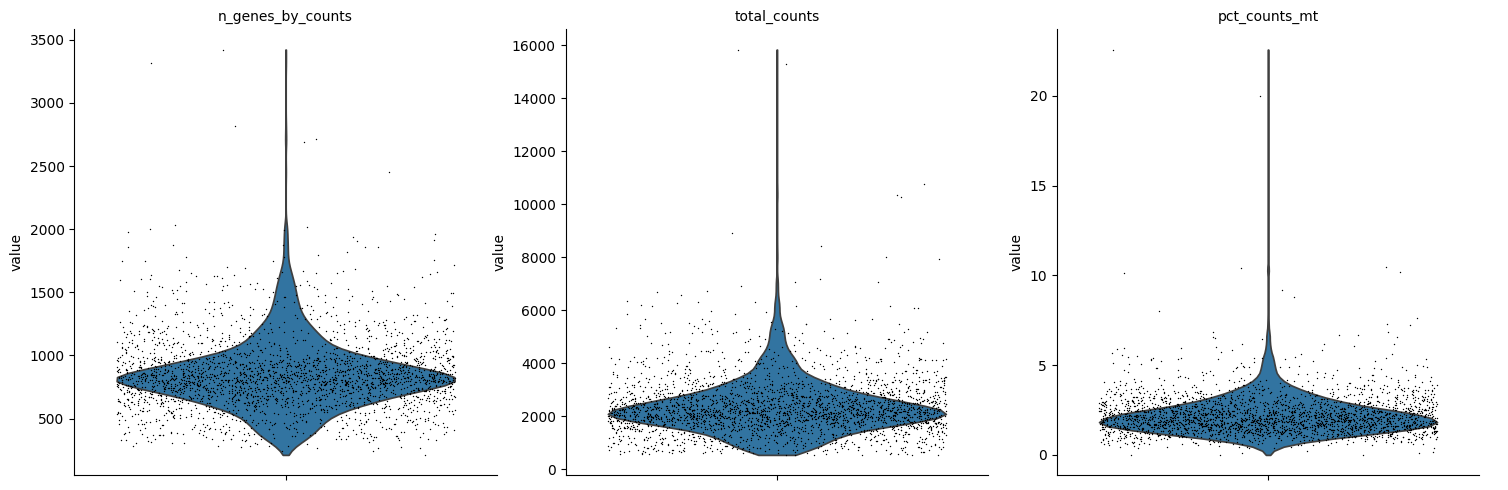

In [9]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

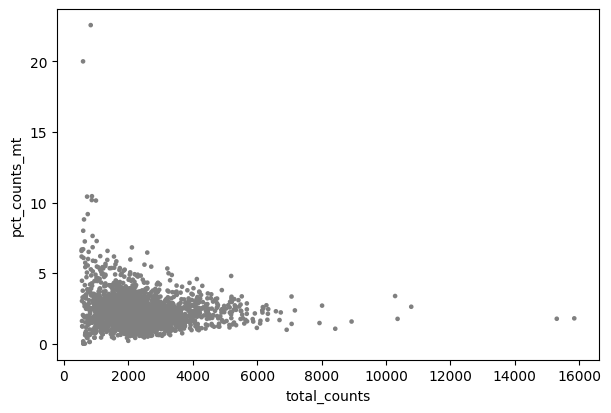

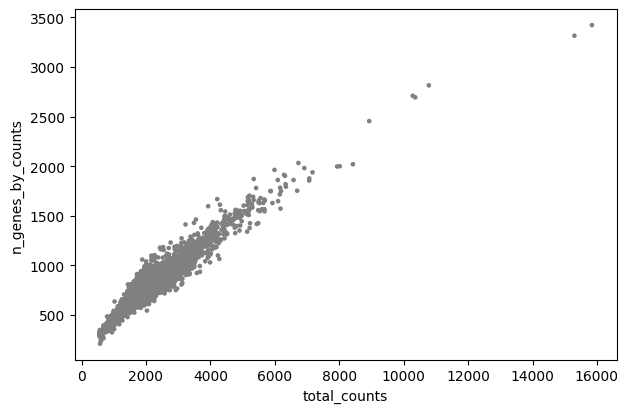

In [10]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

## Filter cells/genes

There seems to be a separation here for us to define a filtering thresholds. I want to remove cells with highly suspicious number of gene counts (low and high), also remove cells with high % of mitochondrial genes (damaged cells). I also want to filter by genes.

In [12]:
adata = adata[
    (adata.obs.n_genes_by_counts > 200) &
    (adata.obs.n_genes_by_counts < 2500) &
    (adata.obs.pct_counts_mt < 5), :
]

adata

View of AnnData object with n_obs × n_vars = 2638 × 32738
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [13]:
sc.pp.filter_genes(adata,min_cells=3)

/Users/zz6/projects/personal/single-cell-clustering-analysis/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:283: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


## Normalise and log-transform

In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Save

In [15]:
Path("..data/processed").mkdir(parents=True, exist_ok=True)
adata.write("../data/processed/adata_qc.h5ad")